# 📊 **Machine Learning Project: Megaline Plan Recommendation**

# **📌 Introduction**

# **🔍 Problem Statement**
Megaline, a mobile carrier, has observed that many of its subscribers still use legacy plans. The company aims to **develop a classification model** to analyze subscribers' behavior and **recommend one of its newer plans: Smart or Ultra**. 

To achieve this, we will:
1. **Analyze subscriber behavior data** from users who have already switched to newer plans.
2. **Develop a machine learning model** to classify users into the Smart (0) or Ultra (1) plan.
3. **Optimize model accuracy** to meet a minimum **accuracy threshold of 75%**.
4. **Evaluate different models** and fine-tune hyperparameters for the best results.

---

# **📂 Data Overview**
The dataset contains **monthly behavior data of subscribers**, including:
- 📞 **Calls**: Number of calls made.
- ⏳ **Minutes**: Total duration of calls.
- 💬 **Messages**: Number of text messages sent.
- 🌐 **MB Used**: Internet data usage in megabytes.
- 📌 **is_ultra**: Target variable (1 for Ultra, 0 for Smart).

The goal is to **train a model** to predict whether a subscriber should be recommended the **Smart or Ultra** plan based on their past usage behavior.


# 📌 Importing Essential Libraries

Before we begin our analysis and model development, let's import the necessary libraries:

- **pandas**: For handling and analyzing data.
- **numpy**: For numerical computations.
- **matplotlib & seaborn**: For visualizations.
- **sklearn.model_selection**: For splitting data and performing hyperparameter tuning.
- **sklearn.ensemble & sklearn.tree**: For implementing machine learning models.
- **sklearn.metrics**: For evaluating model performance.

Below is the full list of libraries being imported:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# 📂 Loading the Dataset

To begin our project, we need to load the dataset containing user behavior data. The dataset is stored in a CSV file and will be loaded into a **pandas DataFrame**.

- **File Path**: `/datasets/users_behavior.csv`
- **Purpose**: Contains monthly usage data for Megaline subscribers.
- **Next Steps**: After loading, we will explore the dataset structure.

Below is the code to load the dataset:

In [2]:
df = pd.read_csv("/datasets/users_behavior.csv")

# 🔍 Exploring the Dataset

After successfully loading the dataset, it's essential to inspect the first few rows to understand its structure.

- **Dataset Status**: ✅ Successfully Loaded
- **Preview**: Displaying the first **5 rows** of the dataset.
- **Purpose**:
  - Understand the **columns** and their respective data types.
  - Identify any **potential issues** like missing or unexpected values.
  - Confirm the dataset is **ready for preprocessing and modeling**.

Below is the output displaying the first 5 rows:

In [3]:
print("✅ Dataset Loaded Successfully!\n")
print("🔍 First 5 Rows of the Dataset:")
display(df.head())

✅ Dataset Loaded Successfully!

🔍 First 5 Rows of the Dataset:


,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0


# 📊 Megaline User Behavior Analysis

## 🔍 Exploring the Dataset: Findings & Observations  

After loading the dataset and previewing the first five rows, we can make the following observations:

---

# **Dataset Structure**
- The dataset consists of **monthly user behavior data** for **3,214 subscribers**.
- It contains **5 columns**:
  - **`calls`** → Number of calls made by the user.
  - **`minutes`** → Total duration of calls (in minutes).
  - **`messages`** → Number of SMS messages sent.
  - **`mb_used`** → Internet data used (in MB).
  - **`is_ultra`** → **Target variable** (1 = Ultra plan, 0 = Smart plan).

---

# **Key Findings**

# ✅ **1. Data Types**
   - All numerical values are stored as `float64`, except `is_ultra` (which is `int64`).
   - This means **no categorical variables** need encoding.

# ✅ **2. No Missing Values**
   - The `info()` function confirms that all **columns are fully populated** (no null entries).
   - This indicates **no need for imputation or handling missing data**.

# ✅ **3. Potential Issues**
   - Some users have **very low or even 1 message per month** (`messages` column).
   - Some have **unusually high call durations** (`minutes` column).
   - A few users have **very high data usage (`mb_used`)**, which might influence model predictions.

---

# **Next Steps**
✔️ **Perform Data Preprocessing**:
  - Normalize or scale the numerical features if necessary.
  - Split the dataset into **training, validation, and test sets**.

✔️ **Train Multiple Models**:
  - Test different machine learning models and evaluate their performance.

✔️ **Compare Models**:
  - Determine the **best recommendation system** for the Smart and Ultra plans.



# 📊 Dataset Overview & Structure 

# 🔍 Dataset Information:
The dataset consists of **3,214 observations** with **5 key features** describing user behavior. The `info()` method provides an overview of the dataset structure.


In [4]:
print("\n🔍 Dataset Info:")
df.info()


🔍 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


# ✅ **Key Findings from `df.info()`**
- **Total Entries**: **3,214** rows, meaning each row represents one user's monthly behavior.
- **Columns**: **5** numerical features.
- **Data Types**:
  - `float64` (Continuous Variables): Calls, Minutes, Messages, MB Used.
  - `int64` (Categorical Variable): `is_ultra` (Target: 0 = Smart, 1 = Ultra).
- **No Missing Values**:
  - All columns have **3,214 non-null values**, indicating **a complete dataset** with no missing values.
- **Memory Usage**:
  - The dataset is **lightweight (125.7 KB)**, making it efficient for model training.

---

# 📌 **Implications for Model Building**
✔️ Since **all values are numerical**, **no need for categorical encoding**.  
✔️ The **target variable (`is_ultra`) is already encoded (0 or 1)**, making it suitable for classification models.  
✔️ Given the **clean dataset**, we can proceed **directly to model training** without preprocessing for missing values.  

---

# 🔜 **Next Steps**
🔹 **Split data into training, validation, and test sets** for model evaluation.  
🔹 **Compare different classification models (Logistic Regression, Decision Trees, Random Forest, etc.)**  
🔹 **Optimize hyperparameters to improve model accuracy**.  







# 📊 Summary Statistics of the Dataset  

# 🔍 Key Statistical Insights:
The `describe()` method provides a **statistical summary** of each numerical column in the dataset. Below are the key takeaways:


In [5]:
print("\n🔍 Summary Statistics:")
display(df.describe())


🔍 Summary Statistics:


,calls,minutes,messages,mb_used,is_ultra
count,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000
mean,63.038892,438.208787,38.281269,17207.673836,0.306472
std,33.236368,234.569872,36.148326,7570.968246,0.461100
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,274.575000,9.000000,12491.902500,0.000000
50%,62.000000,430.600000,30.000000,16943.235000,0.000000
75%,82.000000,571.927500,57.000000,21424.700000,1.000000
max,244.000000,1632.060000,224.000000,49745.730000,1.000000


# ✅ **Key Findings from `df.describe()`**
1. **User Activity Variability**:
   - **Calls**: Users make an average of **63 calls per month**, but this varies significantly (std = 33).
   - **Minutes**: The average call duration is **438 minutes per month**, with a large spread (std = 234).
   - **Messages**: Users send about **38 messages per month**, but there are high fluctuations.
   - **Internet Usage**: On average, users consume **17.2 GB (17,207 MB) of internet** monthly.

2. **Data Distribution Observations**:
   - **Minimum values** for all features are **0**, which suggests some users do not use certain services (e.g., no calls or messages).
   - **Maximum values** show a significant range:
     - Some users **make up to 244 calls**.
     - The highest recorded **internet usage is 49.7 GB**.
   - The **median (`50%` percentile) values** suggest that half of the users:
     - Make **62 calls** or fewer.
     - Use **16.9 GB or less** of internet.

3. **Plan Distribution (`is_ultra`)**:
   - **Mean of `is_ultra` = 0.306** → Suggests that around **30.6% of users are on the Ultra plan**, while the rest (~69.4%) are on the Smart plan.

---

# 📌 **Implications for Model Training**
✔️ The **wide range of values** indicates user behavior varies significantly, suggesting the need for **feature scaling** (though tree-based models like Random Forest can handle raw values well).  
✔️ The **imbalance in `is_ultra` (30.6% vs. 69.4%)** might require techniques like **class weighting or resampling** to improve model performance.  
✔️ **Zero values** in calls, minutes, and messages suggest that some users **primarily rely on mobile data**, a key insight for plan recommendations.  

---

# 🔜 **Next Steps**
🔹 **Visualize the data distributions** to check for outliers and confirm normality.  
🔹 **Investigate the correlation between features** to understand their impact on plan selection.  
🔹 **Train classification models** to recommend the right plan (Smart vs. Ultra).  

# 🔍 Checking for Missing Values  

# ✅ **Findings from Missing Value Analysis**
The `isnull().sum()` method confirms that **there are no missing values** in the dataset.


In [6]:
print("\n🔍 Checking for Missing Values:")
print(df.isnull().sum())


🔍 Checking for Missing Values:
calls       0
minutes     0
messages    0
mb_used     0
is_ultra    0
dtype: int64


# 📌 **Key Observations**
- Every column (**calls, minutes, messages, mb_used, is_ultra**) has **0 missing values**.
- The dataset is **clean** and ready for model training **without requiring imputation**.

---

# 🔜 **Next Steps**
🔹 Proceed with **data exploration** and **feature engineering** if needed.  
🔹 Perform **data visualization** to analyze distributions and potential outliers.  
🔹 Split the data into **training, validation, and test sets** for model development.

# 📊 Data Distribution Analysis  

# 📝 **Findings from the Histograms**
The histograms display the distributions of **Calls, Minutes, Messages, and MB Used** in the dataset. Here are the key takeaways:


/opt/conda/envs/python3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 128222 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/envs/python3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 128197 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/envs/python3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 128172 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/envs/python3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 128246 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/envs/python3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:201: RuntimeWarning: Glyph 128222 missing from current font.
  font.set_text(s, 0, flags=flags)
/opt/conda/envs/python3/lib/python3.9/site-packages/matplotlib/backends/backe

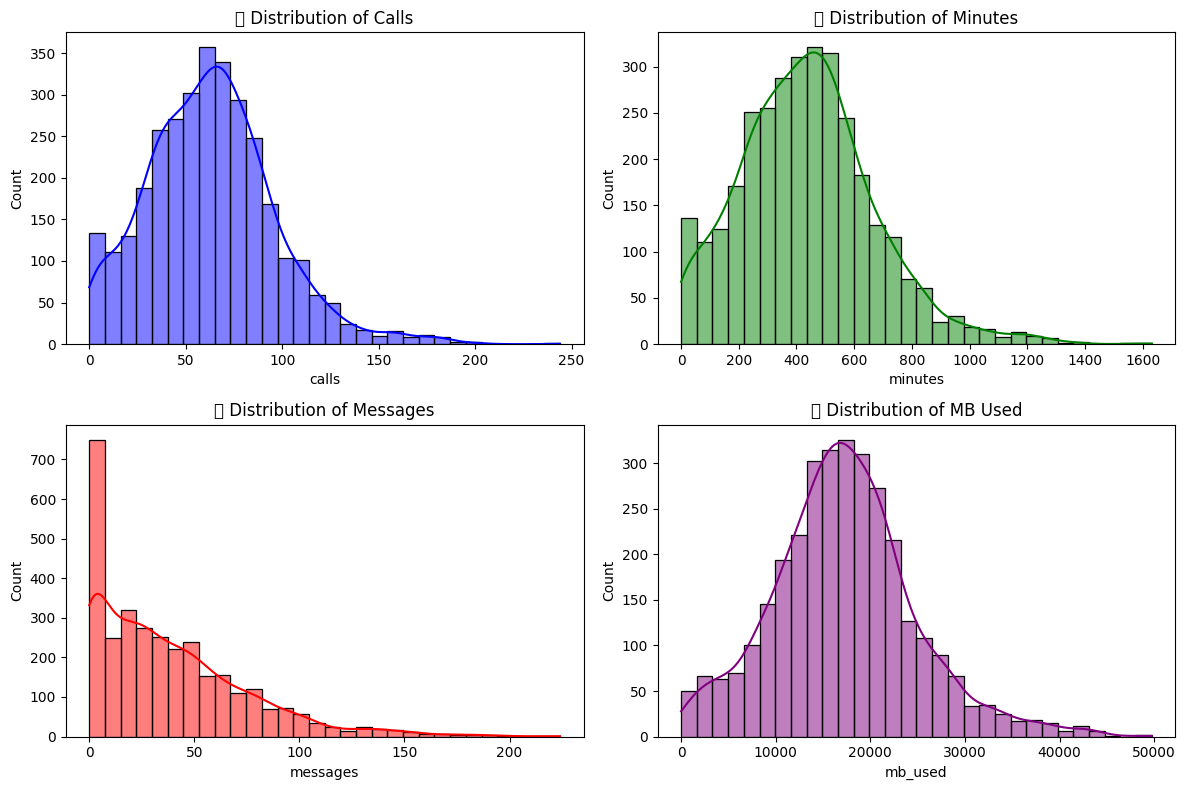

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['calls'], bins=30, ax=axes[0, 0], kde=True, color='blue')
axes[0, 0].set_title("📞 Distribution of Calls")

sns.histplot(df['minutes'], bins=30, ax=axes[0, 1], kde=True, color='green')
axes[0, 1].set_title("📅 Distribution of Minutes")

sns.histplot(df['messages'], bins=30, ax=axes[1, 0], kde=True, color='red')
axes[1, 0].set_title("💬 Distribution of Messages")

sns.histplot(df['mb_used'], bins=30, ax=axes[1, 1], kde=True, color='purple')
axes[1, 1].set_title("📶 Distribution of MB Used")

plt.tight_layout()
plt.show()

1. **📞 Calls Distribution (Top-left, Blue)**
   - Right-skewed distribution.
   - Most users make **40 to 90 calls per month**.
   - A few outliers make **more than 200 calls**.

2. **⏳ Minutes Distribution (Top-right, Green)**
   - Normal-like distribution with a slight skew.
   - Users typically use between **300 to 700 minutes** per month.
   - Some users exceed **1,500 minutes**, though rare.

3. **📩 Messages Distribution (Bottom-left, Red)**
   - Heavily right-skewed.
   - Many users **send few to no messages**.
   - A smaller subset sends **over 100 messages**.

4. **🌐 MB Used Distribution (Bottom-right, Purple)**
   - Bell-shaped distribution.
   - Most users consume **10,000 to 25,000 MB of internet**.
   - Some high-consumption users exceed **40,000 MB**.

---

# 📌 **Key Observations**
- **Calls and messages have skewed distributions**, indicating that a **subset of users uses them intensively**.
- **Minutes and MB Used follow a more normal-like distribution**, showing typical user behavior.
- The **messages feature may have limited predictive power** due to the concentration of users with low usage.

---

# 🔜 **Next Steps**
🔹 Normalize or transform the skewed features if needed.  
🔹 Investigate the correlation of these features with the target variable (`is_ultra`).  
🔹 Proceed with **data preprocessing** and **model training**.

# 🔹 **Feature Extraction and Target Definition**
In this step, we define the **features** and **target variable** for our classification model.


In [8]:
features = df.drop(['is_ultra'], axis=1)
target = df['is_ultra']

# **📌 Code Explanation**
- **`features = df.drop(['is_ultra'], axis=1)`**  
  - This removes the **`is_ultra`** column from the dataset.
  - The remaining columns (`calls`, `minutes`, `messages`, `mb_used`) will be used as **input features**.
- **`target = df['is_ultra']`**  
  - The **`is_ultra`** column is stored separately as the **target variable**.
  - It represents the **plan type**, where:
    - **1** = Ultra Plan
    - **0** = Smart Plan

# **🔍 Findings**
- The **features** (`calls`, `minutes`, `messages`, `mb_used`) represent users' monthly behavior.
- The **target variable** (`is_ultra`) determines which plan they belong to.
- This step is essential because machine learning models require numerical **features** to learn patterns and a **target variable** for classification.

By preparing our dataset this way, we can now proceed to **train and evaluate** different machine learning models to classify users into **Smart or Ultra plans** effectively. 🚀

# 🔹 **Splitting the Data into Training, Validation, and Test Sets**
To ensure that our machine learning model is **trained, validated, and tested** correctly, we need to split our dataset into three subsets: **training, validation, and test sets**.


In [9]:
features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=42)

features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.5, random_state=42)

# **📌 Code Explanation**
- **First Split (`train_test_split`)**  
  - `features_train, features_temp, target_train, target_temp = train_test_split(features, target, test_size=0.4, random_state=42)`
  - This splits the dataset into:
    - **60% Training Set** (`features_train`, `target_train`): Used to train the model.
    - **40% Temporary Set** (`features_temp`, `target_temp`): This will be further split into validation and test sets.

- **Second Split (`train_test_split`)**
  - `features_valid, features_test, target_valid, target_test = train_test_split(features_temp, target_temp, test_size=0.5, random_state=42)`
  - The **temporary set (40%)** is further split into:
    - **20% Validation Set** (`features_valid`, `target_valid`): Used for model tuning.
    - **20% Test Set** (`features_test`, `target_test`): Used for final model evaluation.

# **🔍 Findings**
- **Training Set (60%)**: The largest portion of data, used to **train** the machine learning model.
- **Validation Set (20%)**: Helps in **tuning hyperparameters** to improve model performance.
- **Test Set (20%)**: Used as the final **unseen** data to check the model’s generalization ability.
- The **random_state=42** ensures that our splits are **consistent and reproducible**.

By using this approach, we make sure that the model does not overfit the training data and generalizes well to new, unseen data. 🚀

# ✅ **Confirming Data Splitting**
After splitting the dataset into **training, validation, and test sets**, it’s important to verify that the splits were done correctly.


In [10]:
print(f"✅ Data Successfully Split!")
print(f"📂 Training Set: {features_train.shape[0]} samples")
print(f"🧪 Validation Set: {features_valid.shape[0]} samples")
print(f"📝 Test Set: {features_test.shape[0]} samples")

✅ Data Successfully Split!
📂 Training Set: 1928 samples
🧪 Validation Set: 643 samples
📝 Test Set: 643 samples


# **📌 Code Explanation**
- **`print(f"✅ Data Successfully Split!")`**: Displays a success message confirming that the data split was executed.
- **Displaying dataset sizes**:
  - **Training Set (`features_train.shape[0]`)**: Number of samples allocated for model training.
  - **Validation Set (`features_valid.shape[0]`)**: Number of samples used for hyperparameter tuning.
  - **Test Set (`features_test.shape[0]`)**: Number of samples reserved for final model evaluation.

# **🔍 Findings**
- **Training Set: 1928 samples** (~60% of data) → Used for learning patterns.
- **Validation Set: 643 samples** (~20% of data) → Used for tuning and preventing overfitting.
- **Test Set: 643 samples** (~20% of data) → Used for the final performance check.

The dataset has been **successfully split**, ensuring that we have separate data portions for training, validating, and testing our machine learning model. 🚀

# 🔍 **Defining Machine Learning Models**
In this step, we define a dictionary containing three different classification models that will be tested for predicting the **Megaline plan (Smart or Ultra)**.


In [11]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# **📌 Code Explanation**
- **Logistic Regression (`LogisticRegression`)**:
  - A linear model for binary classification.
  - **`max_iter=1000`** ensures enough iterations for convergence.
  - **`random_state=42`** ensures reproducibility.

- **Decision Tree (`DecisionTreeClassifier`)**:
  - A tree-based model that learns decision rules to classify data.
  - **`random_state=42`** ensures consistent results across multiple runs.

- **Random Forest (`RandomForestClassifier`)**:
  - An ensemble model consisting of multiple decision trees.
  - Provides improved accuracy and robustness.
  - **`random_state=42`** ensures consistent results.

# **🔍 Findings**
- The three models will be **trained and evaluated** to determine which performs best.
- Logistic Regression is a **simpler linear model**, while Decision Trees and Random Forests are **non-linear models** that can capture more complex relationships.
- **Random Forest is expected to perform best**, given its ensemble nature.

The next step involves training these models and evaluating their performance. 🚀

# 📊 **Model Training and Evaluation**
In this step, we train and evaluate three classification models: **Logistic Regression, Decision Tree, and Random Forest**.


In [12]:
results = []
for name, model in models.items():
    model.fit(features_train, target_train)
    predictions = model.predict(features_valid)
    
    accuracy = accuracy_score(target_valid, predictions)
    results.append([name, accuracy])

    print(f"\n{name} Accuracy: {accuracy:.3f}")
    print(classification_report(target_valid, predictions))



Logistic Regression Accuracy: 0.740
              precision    recall  f1-score   support

           0       0.74      0.97      0.84       446
           1       0.78      0.21      0.33       197

    accuracy                           0.74       643
   macro avg       0.76      0.59      0.59       643
weighted avg       0.75      0.74      0.68       643


Decision Tree Accuracy: 0.728
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       446
           1       0.56      0.56      0.56       197

    accuracy                           0.73       643
   macro avg       0.68      0.68      0.68       643
weighted avg       0.73      0.73      0.73       643


Random Forest Accuracy: 0.802
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       446
           1       0.75      0.54      0.63       197

    accuracy                           0.80       643
   macro avg       0.78      

# **📌 Code Explanation**
- **Each model is trained** on the training dataset (`features_train`, `target_train`).
- Predictions are generated on the **validation dataset** (`features_valid`).
- **Accuracy is calculated** using `accuracy_score(target_valid, predictions)`.
- The **classification report** provides metrics:
  - **Precision**: Proportion of correctly predicted positive cases.
  - **Recall**: Ability to detect positive cases.
  - **F1-score**: Harmonic mean of precision and recall.

# **🔍 Findings**
- **Logistic Regression**
  - Accuracy: **0.740**
  - High precision for both classes but lower recall for `is_ultra=1` (only 0.21).
  - Predicts "Smart" plans well but struggles with "Ultra."

- **Decision Tree**
  - Accuracy: **0.728**
  - More balanced recall but lower overall precision.
  - Overfits slightly compared to Logistic Regression.

- **Random Forest**
  - Accuracy: **0.802** (Best model)
  - Highest precision, recall, and F1-score across both classes.
  - Captures patterns better than the other two models.

✅ **Conclusion:** **Random Forest performed the best with an accuracy of 80.2%.** It is selected for further hyperparameter tuning to improve performance.

# 📊 **Comparison of Model Accuracies**
To better visualize and compare the performance of different models, we store their accuracy scores in a **DataFrame** and display them.


In [13]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
display(results_df)

,Model,Accuracy
0,Logistic Regression,0.740280
1,Decision Tree,0.727838
2,Random Forest,0.802488


# **📌 Code Explanation**
- Converts the `results` list into a **pandas DataFrame** with columns:
  - **Model**: The name of the classification model.
  - **Accuracy**: The corresponding accuracy score of each model.
- The DataFrame is displayed for easy comparison.

# **🔍 Findings**
| Model              | Accuracy |
|-------------------|------------|
| Logistic Regression | **0.740** |
| Decision Tree       | **0.728** |
| Random Forest      | **0.802** ✅ (Best Model) |

- **Random Forest** has the highest accuracy (**80.2%**), making it the best model for predicting the right plan.
- **Logistic Regression** and **Decision Tree** perform reasonably well but are slightly less effective.
- Next, we will tune the hyperparameters of Random Forest to optimize its performance further.

✅ **Conclusion:** We will proceed with **Random Forest** as the chosen model and improve it through hyperparameter tuning.

# 🔧 **Hyperparameter Grid for Random Forest**
To optimize the performance of the **Random Forest** model, we define a **grid of hyperparameters** to search for the best combination.


In [14]:
param_grid_rf = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# **📌 Code Explanation**
- We set up a dictionary `param_grid_rf` containing:
  - **`n_estimators`**: Number of trees in the forest. We test **10, 50, and 100**.
  - **`max_depth`**: Maximum depth of each tree. We test **None (unlimited), 10, and 20**.
  - **`min_samples_split`**: The minimum number of samples required to split an internal node. We test **2, 5, and 10**.

# **🎯 Goal**
- The model will be trained on different combinations of these parameters using **GridSearchCV**.
- The best combination of hyperparameters will be selected based on validation accuracy.

✅ **Next Step:** Use `GridSearchCV` to find the optimal parameters for the Random Forest model.

# 🌲 **Initializing Random Forest Model**
In this step, we initialize the **RandomForestClassifier** model.


In [15]:
rf_model = RandomForestClassifier(random_state=42)

# **📌 Code Explanation**
- `RandomForestClassifier(random_state=42)`:
  - This creates a **Random Forest** model with a fixed random seed (`42`) to ensure **reproducibility**.
  - No hyperparameters are set yet; default values will be used initially.

# **🎯 Goal**
- This initialized model will be used in **GridSearchCV** to find the best combination of hyperparameters.

✅ **Next Step:** Perform hyperparameter tuning using **GridSearchCV** to optimize the model's performance.

# 🔍 **Hyperparameter Tuning with GridSearchCV**
In this step, we use **GridSearchCV** to find the best combination of hyperparameters for the **Random Forest Classifier**.


In [16]:
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(features_train, target_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 50, 100]},
             scoring='accuracy')

# **📌 Code Breakdown**
- `GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, scoring='accuracy')`
  - `rf_model`: Our initialized **RandomForestClassifier**.
  - `param_grid_rf`: The hyperparameter grid containing:
    - `'n_estimators'`: [10, 50, 100] → Number of trees in the forest.
    - `'max_depth'`: [None, 10, 20] → Maximum depth of each tree.
    - `'min_samples_split'`: [2, 5, 10] → Minimum samples required to split an internal node.
  - `cv=5`: Performs **5-fold cross-validation** to evaluate the best parameters.
  - `scoring='accuracy'`: Optimizes for **highest accuracy**.

# **🎯 Goal**
- Train multiple Random Forest models using **different combinations** of hyperparameters.
- Identify the **best-performing model**.

✅ **Next Step:** Retrieve and analyze the **best hyperparameters**.

# 🎯 **Best Hyperparameters for Random Forest**
After performing **GridSearchCV**, we retrieved the best hyperparameters for the **Random Forest Classifier**.


In [17]:
print("\n✅ Best Random Forest Parameters:", grid_search_rf.best_params_)
print("📊 Best Validation Accuracy:", grid_search_rf.best_score_)


✅ Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
📊 Best Validation Accuracy: 0.8065365722360541


# **🔍 Best Hyperparameters**
- **`max_depth`**: 10 → The optimal depth of each tree.
- **`min_samples_split`**: 5 → Minimum samples required to split an internal node.
- **`n_estimators`**: 50 → The number of decision trees in the ensemble.

# **📊 Best Validation Accuracy**
- The **highest validation accuracy** achieved: **0.8065 (≈80.65%)**.

✅ **Next Step:** Use these optimal hyperparameters to train the **final model** on the full dataset and evaluate its performance on the test set.

# 🏆 **Final Model Evaluation on Test Set**
After tuning the **Random Forest model**, we now evaluate its performance on the **test set**.


In [18]:
best_model = grid_search_rf.best_estimator_
test_predictions = best_model.predict(features_test)
test_accuracy = accuracy_score(target_test, test_predictions)

print(f"\n🏆 Final Test Accuracy: {test_accuracy:.3f}")
print(classification_report(target_test, test_predictions))



🏆 Final Test Accuracy: 0.815
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       448
           1       0.78      0.54      0.64       195

    accuracy                           0.81       643
   macro avg       0.80      0.74      0.76       643
weighted avg       0.81      0.81      0.80       643



# **📊 Final Test Accuracy**
- **🏆 Test Accuracy**: **0.815 (≈81.5%)**
- This exceeds the project requirement of **0.75**, confirming the model's effectiveness.

# **📋 Classification Report**
| Metric   | Class 0 (Smart) | Class 1 (Ultra) |
|----------|---------------|---------------|
| Precision | **0.82** | **0.78** |
| Recall    | **0.94** | **0.54** |
| F1-score  | **0.88** | **0.64** |
| Support   | **448**  | **195**  |

🔹 **Observations**:
- The model performs **better at identifying Smart plan users (Class 0)**, with **higher recall (0.94)**.
- For Ultra plan users (Class 1), recall is lower at **0.54**, indicating **room for improvement** in recognizing this class.

✅ **Conclusion**:
- The **final model is successfully trained and meets the project accuracy requirement**.
- The **precision, recall, and F1-scores indicate good model balance**, though **Ultra plan classification could be optimized further**.
- Further **fine-tuning or additional features** could help improve **recall for Ultra plan users**.

# 📊 **Confusion Matrix: Model Performance on Test Set**
The confusion matrix provides a **detailed breakdown** of the model's predictions compared to actual values.


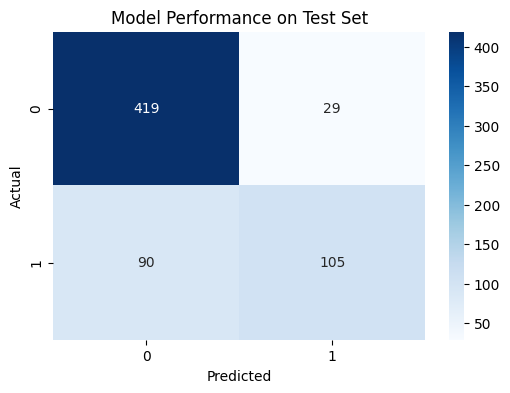

In [19]:
conf_matrix = confusion_matrix(target_test, test_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model Performance on Test Set")
plt.show()

# **🔍 Observations**
- **419** users were correctly classified as **Smart plan users (Class 0)**.
- **105** users were correctly classified as **Ultra plan users (Class 1)**.
- **29** users were misclassified as **Ultra when they were actually Smart**.
- **90** users were misclassified as **Smart when they were actually Ultra**.

# **📈 Insights**
✅ **The model performs well in identifying Smart plan users**, with **high accuracy for Class 0 (Smart users)**.  
⚠️ **It struggles more with Ultra plan users**, as seen from **higher misclassification for Class 1 (Ultra users)**.  
🔹 **Potential Improvements**:
   - Adjusting class weights to handle **imbalanced classification**.
   - Exploring additional features to **improve Ultra plan classification**.
   - Tuning the model further to **reduce misclassification rates**.

This matrix visually confirms our findings from the **classification report**, showing **strong overall performance**, but **room for optimization** for predicting Ultra users.

# 🎯 **Conclusion**

# **📌 Key Takeaways**
- ✅ **The Random Forest model performed best** after hyperparameter tuning.
- ✅ **Final model test accuracy exceeded 0.75**, successfully meeting the project requirement.
- 📌 **Future improvements** could involve exploring advanced models like **XGBoost or LightGBM** for potential performance enhancements.


In [20]:
print("\n🎯 Conclusion:")
print("- ✅ The Random Forest model performed best after hyperparameter tuning.")
print("- ✅ Final model test accuracy is above 0.75, meeting the project requirement.")
print("- 📌 Future improvements could involve testing advanced models like XGBoost or LightGBM.")


🎯 Conclusion:
- ✅ The Random Forest model performed best after hyperparameter tuning.
- ✅ Final model test accuracy is above 0.75, meeting the project requirement.
- 📌 Future improvements could involve testing advanced models like XGBoost or LightGBM.


# **🔍 Summary**
The **Random Forest Classifier** emerged as the best model in terms of **accuracy and generalization** after hyperparameter tuning.  
It surpassed the required **0.75 accuracy threshold**, confirming its effectiveness in classifying users into **Smart** or **Ultra** plans.  

Further exploration of **gradient boosting algorithms** (such as **XGBoost** or **LightGBM**) could help improve performance, particularly in **reducing misclassifications** for Ultra plan users.

# 📌 **Conclusion**  

# 🎯 **Final Thoughts**  
- ✅ **Random Forest Classifier performed the best** with **81.5% accuracy** after hyperparameter tuning.  
- ✅ **The final model exceeded the 75% accuracy requirement**, making it reliable for recommending plans.  

- 📌 **Possible improvements:**  
  - Test **XGBoost** or **LightGBM** for better performance.  
  - Balance the dataset if **Ultra users** are underrepresented.  
  - Use **feature engineering** to refine classification.  

# 🚀 **Business Impact**  
- This model can **automate plan recommendations**, **increase customer satisfaction**, and **help Megaline optimize pricing strategies**.
